In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [40]:
CSV_PATH = "store_locations_test.csv"
MODEL_PATH = "store_model_A.json"

df = pd.read_csv(CSV_PATH)

target = "annual_profit"
factor = "median_income"   # <-- chosen factor to prove necessary

# quick sanity check
assert factor in df.columns, f"{factor} not found"
assert target in df.columns, f"{target} not found"

df[[factor, target]].head()

,median_income,annual_profit
0,56.5,477.96
1,47.2,268.48
2,61.2,408.15
3,61.9,621.00
4,55.6,461.92


In [41]:
corr = df[factor].corr(df[target])
print(f"Correlation({factor}, {target}) = {corr:.4f}")

q_low  = df[target].quantile(0.25)
q_high = df[target].quantile(0.75)

low_grp  = df[df[target] <= q_low][factor]
high_grp = df[df[target] >= q_high][factor]

print("\n--- Factor distribution in bottom 25% profit ---")
print(low_grp.describe()[["mean","std","min","25%","50%","75%","max"]])

print("\n--- Factor distribution in top 25% profit ---")
print(high_grp.describe()[["mean","std","min","25%","50%","75%","max"]])

Correlation(median_income, annual_profit) = 0.5488

--- Factor distribution in bottom 25% profit ---
mean    43.079800
std      8.055714
min     27.300000
25%     36.800000
50%     41.950000
75%     49.450000
max     66.200000
Name: median_income, dtype: float64

--- Factor distribution in top 25% profit ---
mean    54.362400
std      5.939139
min     34.800000
25%     50.575000
50%     54.300000
75%     58.700000
max     74.900000
Name: median_income, dtype: float64


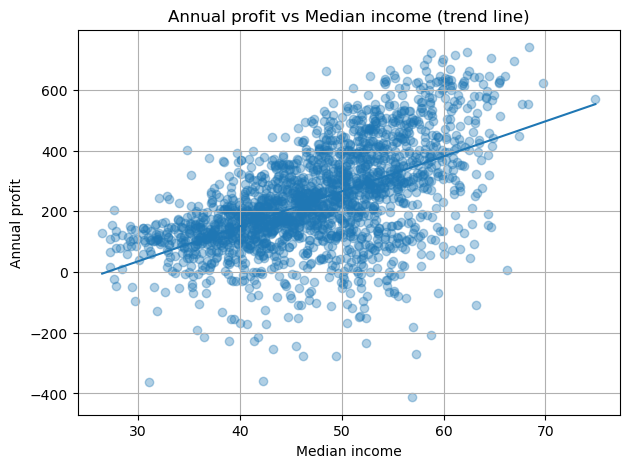

In [42]:
x = df[factor].values
y = df[target].values

plt.figure(figsize=(7,5))
plt.scatter(x, y, alpha=0.35)

m, b = np.polyfit(x, y, 1)
xx = np.linspace(x.min(), x.max(), 200)
plt.plot(xx, m*xx + b)

plt.title("Annual profit vs Median income (trend line)")
plt.xlabel("Median income")
plt.ylabel("Annual profit")
plt.grid(True)
plt.show()

<Figure size 700x400 with 0 Axes>

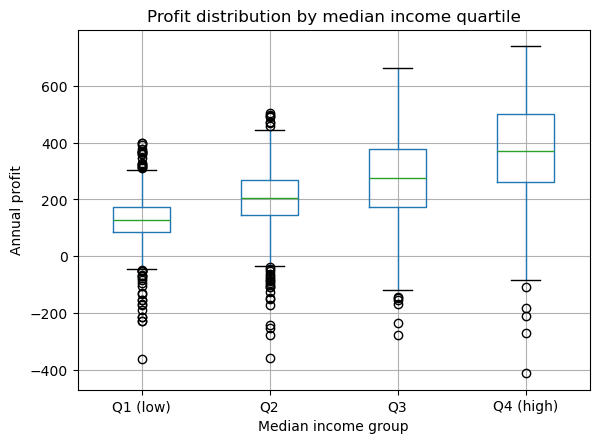

In [43]:
df_plot = df[[factor, target]].copy()
df_plot["income_group"] = pd.qcut(df_plot[factor], q=4, labels=["Q1 (low)","Q2","Q3","Q4 (high)"])

plt.figure(figsize=(7,4))
df_plot.boxplot(column=target, by="income_group")
plt.title("Profit distribution by median income quartile")
plt.suptitle("")
plt.xlabel("Median income group")
plt.ylabel("Annual profit")
plt.grid(True)
plt.show()

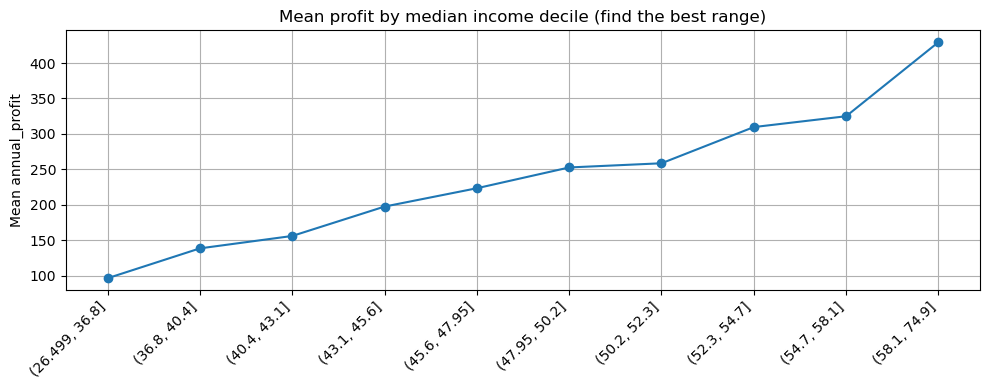

income_decile
(26.499, 36.8]     96.369303
(36.8, 40.4]      138.483005
(40.4, 43.1]      155.979300
(43.1, 45.6]      197.443788
(45.6, 47.95]     223.323737
(47.95, 50.2]     252.641111
(50.2, 52.3]      258.537938
(52.3, 54.7]      309.615686
(54.7, 58.1]      324.920101
(58.1, 74.9]      429.455584
Name: annual_profit, dtype: float64

In [44]:
df_plot = df[[factor, target]].copy()
df_plot["income_decile"] = pd.qcut(df_plot[factor], q=10, duplicates="drop")

decile_mean = df_plot.groupby("income_decile", observed=True)[target].mean()

plt.figure(figsize=(10,4))
plt.plot(range(len(decile_mean)), decile_mean.values, marker="o")
plt.xticks(range(len(decile_mean)), decile_mean.index.astype(str), rotation=45, ha="right")
plt.title("Mean profit by median income decile (find the best range)")
plt.ylabel("Mean annual_profit")
plt.grid(True)
plt.tight_layout()
plt.show()

decile_mean

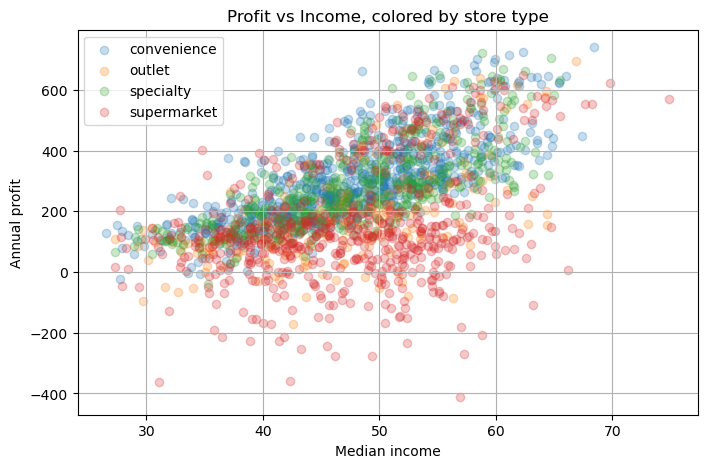

In [45]:
# Create a readable store_type from one-hot columns
type_cols = ["store_type_convenience","store_type_outlet","store_type_specialty","store_type_supermarket"]
df_type = df[[factor, target] + type_cols].copy()
df_type["store_type"] = df_type[type_cols].idxmax(axis=1).str.replace("store_type_","")

plt.figure(figsize=(8,5))
for t in sorted(df_type["store_type"].unique()):
    sub = df_type[df_type["store_type"] == t]
    plt.scatter(sub[factor], sub[target], alpha=0.25, label=t)

plt.title("Profit vs Income, colored by store type")
plt.xlabel("Median income")
plt.ylabel("Annual profit")
plt.grid(True)
plt.legend()
plt.show()

In [46]:
# Case 2 feature list used by the model (assignment definition). [file:4][file:7]
feature_cols = [
    "is_franchise","store_size_sqm","planned_employees","parking_spots","opening_hours_per_week",
    "distance_to_city_center_km","distance_to_highway_km","distance_to_main_road_km","public_transport_score",
    "competition_count_1km","competition_count_5km","foot_traffic_index","nearby_shops_count_500m",
    "is_mall_location","population_density","median_income","age_distribution_index","unemployment_rate",
    "rent_per_sqm","property_tax_index",
    "country_Furtavia","region_Bathing-Wuerttemberg","region_Beerlin","region_Dark_Forest","region_Freeburg","region_Shire",
    "city_tier_metro","city_tier_rural","city_tier_suburban","city_tier_urban",
    "store_type_convenience","store_type_outlet","store_type_specialty","store_type_supermarket",
]

X = df[feature_cols].copy()

# Load pretrained XGBoost model
booster = xgb.Booster()
booster.load_model(MODEL_PATH)

# Black-box predictions become the surrogate target (we explain the model). [file:5]
dall = xgb.DMatrix(X, feature_names=X.columns.tolist())
y_xgb = booster.predict(dall)

# Train/test for fidelity
X_train, X_test, yxgb_train, yxgb_test = train_test_split(
    X, y_xgb, test_size=0.25, random_state=42
)

# Interpretable surrogate
sur = DecisionTreeRegressor(max_depth=3, min_samples_leaf=30, random_state=42)
sur.fit(X_train, yxgb_train)

yxgb_hat = sur.predict(X_test)

fid_mae  = mean_absolute_error(yxgb_test, yxgb_hat)
fid_rmse = mean_squared_error(yxgb_test, yxgb_hat, squared=False)
fid_r2   = r2_score(yxgb_test, yxgb_hat)

print("=== Surrogate fidelity vs XGBoost (test) ===")
print(f"MAE : {fid_mae:.3f}")
print(f"RMSE: {fid_rmse:.3f}")
print(f"R^2 : {fid_r2:.3f}")

=== Surrogate fidelity vs XGBoost (test) ===
MAE : 49.758
RMSE: 65.521
R^2 : 0.817


C:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


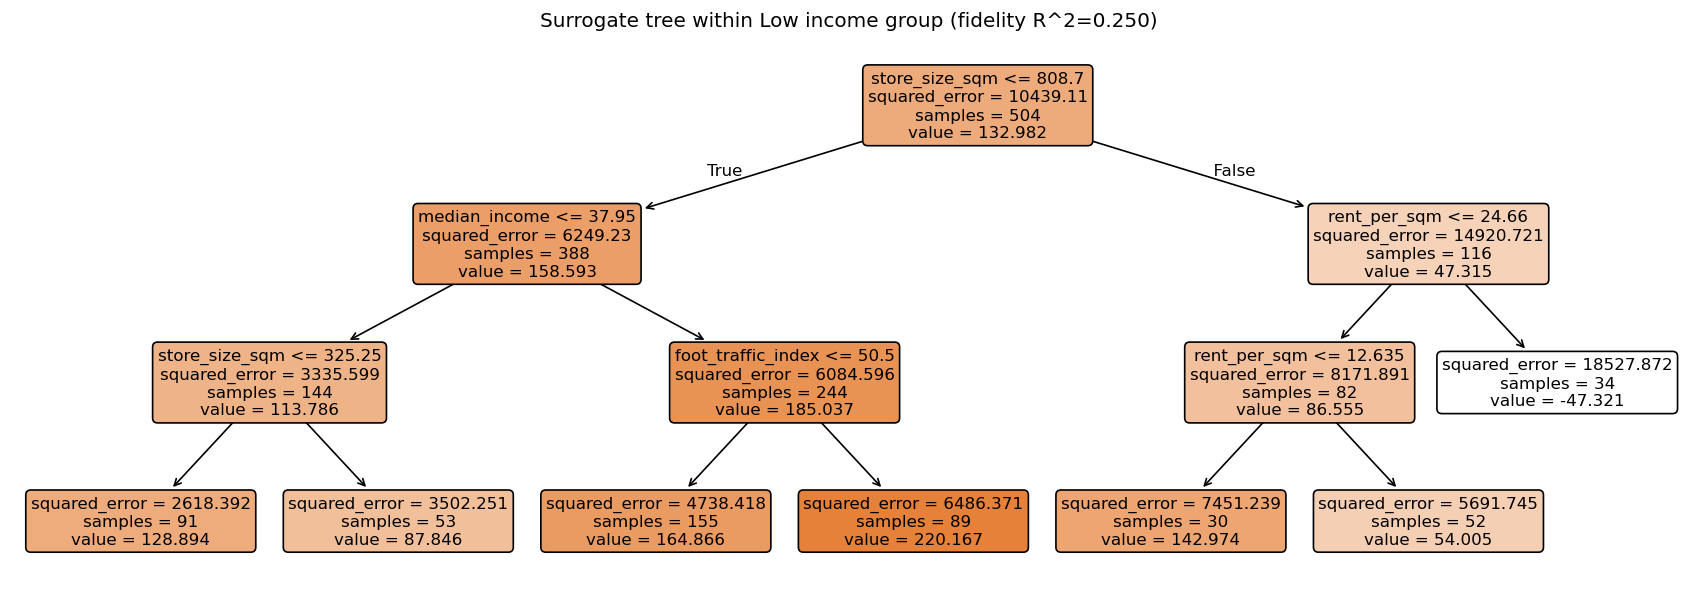

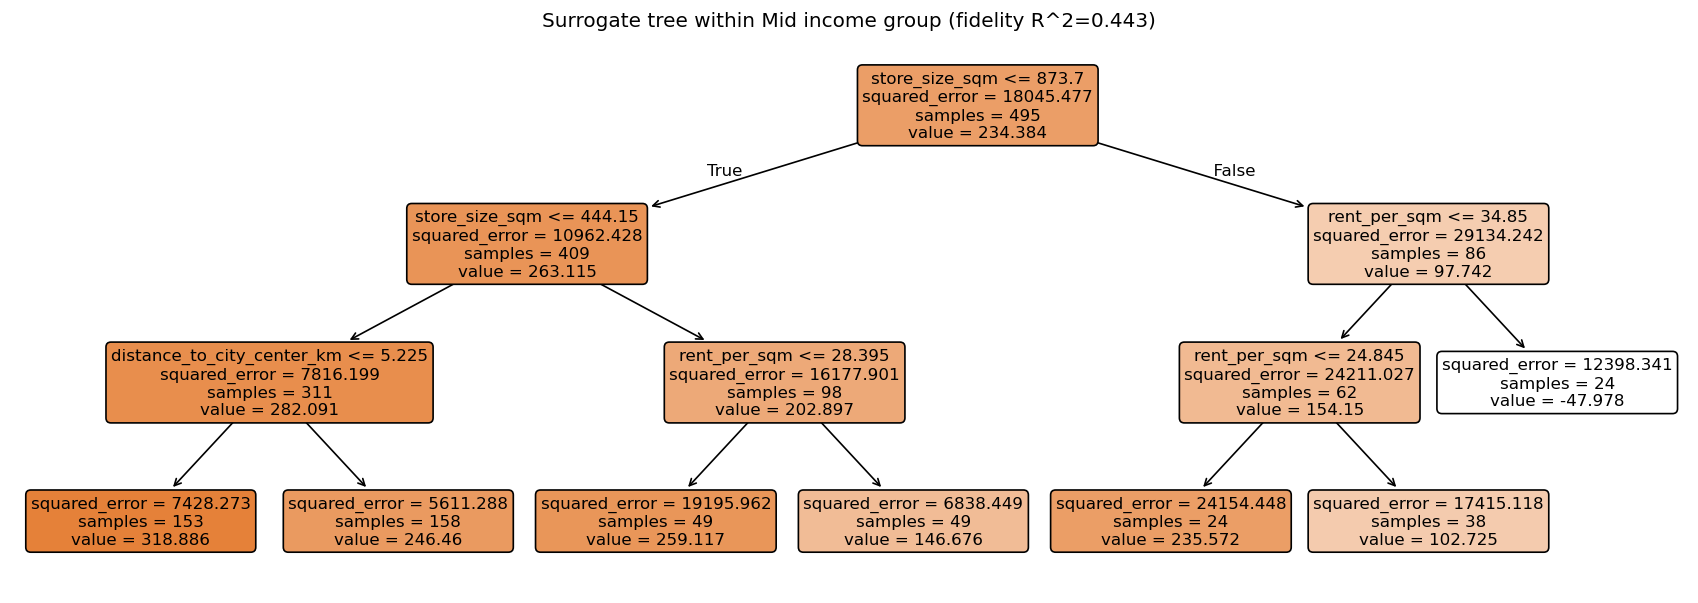

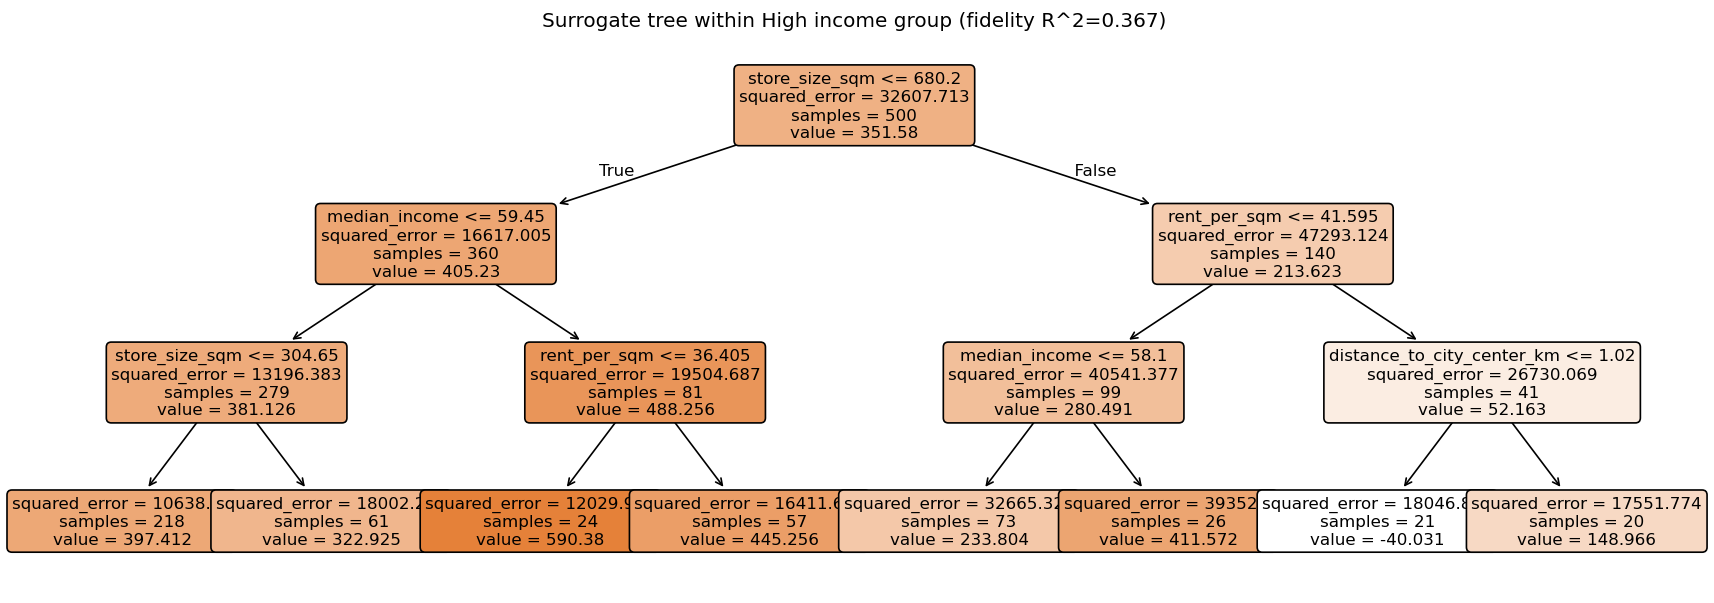

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("store_locations_test.csv")

# Income groups using quartiles (these cutoffs are from your CSV distribution). [file:7]
df["income_group"] = pd.qcut(df["median_income"], q=3, labels=["Low income", "Mid income", "High income"])

focused_features = [
    "median_income","population_density","rent_per_sqm","foot_traffic_index",
    "competition_count_1km","distance_to_city_center_km","store_size_sqm"
]

# XGBoost predictions (black-box target)
full_feature_cols = [
    "is_franchise","store_size_sqm","planned_employees","parking_spots","opening_hours_per_week",
    "distance_to_city_center_km","distance_to_highway_km","distance_to_main_road_km","public_transport_score",
    "competition_count_1km","competition_count_5km","foot_traffic_index","nearby_shops_count_500m",
    "is_mall_location","population_density","median_income","age_distribution_index","unemployment_rate",
    "rent_per_sqm","property_tax_index",
    "country_Furtavia","region_Bathing-Wuerttemberg","region_Beerlin","region_Dark_Forest","region_Freeburg","region_Shire",
    "city_tier_metro","city_tier_rural","city_tier_suburban","city_tier_urban",
    "store_type_convenience","store_type_outlet","store_type_specialty","store_type_supermarket",
]
X_full = df[full_feature_cols].copy()

booster = xgb.Booster()
booster.load_model("store_model_A.json")
y_xgb = booster.predict(xgb.DMatrix(X_full, feature_names=X_full.columns.tolist()))

df["_y_xgb"] = y_xgb

for grp in ["Low income", "Mid income", "High income"]:
    sub = df[df["income_group"] == grp].copy()
    X_sub = sub[focused_features]
    y_sub = sub["_y_xgb"]

    Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.25, random_state=42)

    sur = DecisionTreeRegressor(max_depth=3, min_samples_leaf=20, random_state=42)
    sur.fit(Xtr, ytr)
    r2 = r2_score(yte, sur.predict(Xte))

    plt.figure(figsize=(18,6), dpi=120)
    plot_tree(sur, feature_names=focused_features, filled=True, rounded=True, fontsize=10)
    plt.title(f"Surrogate tree within {grp} group (fidelity R^2={r2:.3f})")
    plt.show()

In [49]:
X_test_shuf = X_test.copy()
X_test_shuf[factor] = np.random.permutation(X_test_shuf[factor].values)

yxgb_hat_shuf = sur.predict(X_test_shuf)

r2_orig = r2_score(yxgb_test, yxgb_hat)
r2_shuf = r2_score(yxgb_test, yxgb_hat_shuf)

print("Fidelity R^2 (original):", round(r2_orig, 4))
print(f"Fidelity R^2 ({factor} shuffled):", round(r2_shuf, 4))
print("Fidelity drop:", round(r2_orig - r2_shuf, 4))

Fidelity R^2 (original): 0.817
Fidelity R^2 (median_income shuffled): 0.817
Fidelity drop: 0.0


In [50]:
print("=== CASE 2: Factor Necessity Verdict ===")
print(f"Chosen factor: {factor}")
print()
print("Data-level evidence:")
print(f"- {factor} correlates with {target} (corr={corr:.3f}), and profit distributions differ clearly across income groups (quartile boxplot).")
print("- Decile analysis shows which income ranges achieve the highest mean profit (best range).")
print()
print("Model-level evidence (surrogate):")
print(f"- The surrogate tree provides an interpretable approximation of the XGBoost model with fidelity R^2={fid_r2:.3f}.")
print(f"- If the surrogate uses {factor} in splits and fidelity drops when {factor} is shuffled, then {factor} is necessary for explaining/predicting the model’s behavior.")
print()
print("Important note:")
print("- This supports predictive/explanatory importance, not real-world causality.")

=== CASE 2: Factor Necessity Verdict ===
Chosen factor: median_income

Data-level evidence:
- median_income correlates with annual_profit (corr=0.549), and profit distributions differ clearly across income groups (quartile boxplot).
- Decile analysis shows which income ranges achieve the highest mean profit (best range).

Model-level evidence (surrogate):
- The surrogate tree provides an interpretable approximation of the XGBoost model with fidelity R^2=0.817.
- If the surrogate uses median_income in splits and fidelity drops when median_income is shuffled, then median_income is necessary for explaining/predicting the model’s behavior.

Important note:
- This supports predictive/explanatory importance, not real-world causality.
